# Rock–Paper–Scissors with Bayesian Learning and Hidden Markov Model

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## General setup

In [2]:
rng = np.random.default_rng(5058)

mappings = {
    "R": 0,
    "P": 1,
    "S": 2,
}

# 0 - Tie
# 1 - First wins
# 2 - Second wins
def define_winner(first_choice, second_choice):
    result = (first_choice - second_choice) % 3
    return 1 if result == 1 else -1 if result == 2 else 0

## Opponent setup

In [9]:
def generate_transition_matrix():
    matrix = rng.random((3, 3))
    return matrix / matrix.sum(axis=1, keepdims=True)

opponent_matrix = generate_transition_matrix()

def get_opponent_move(previous): return rng.choice(3, p = opponent_matrix[previous])

## Learner setup

In [29]:
learner_matrix = np.ones((3, 3))

def normalize_learner_matrix(): return learner_matrix / learner_matrix.sum(axis=1, keepdims=True)
def predict_opponent_move(previous): return np.argmax(normalize_learner_matrix()[previous])
def get_learner_move(previous): return (predict_opponent_move(previous) + 1) % 3
def update_learner_matrix(previous, current): learner_matrix[previous][current] += 1

## Statistics

In [90]:
stats = {"draws": 0, "learner_wins": 0, "opponent_wins": 0}

def update_wins_quantities(result):
    if result == 0: stats["draws"] += 1
    elif result == 1: stats["learner_wins"] += 1
    elif result == -1: stats["opponent_wins"] += 1

scores = []
cumulative_score = 0

def update_net_advantage(result):
    global cumulative_score
    cumulative_score += result
    scores.append(cumulative_score)

def update_stats(result):
    update_net_advantage(result)
    update_wins_quantities(result)

winrates_x = []
winrates_y = []
def update_winrate(game_number):
    winrates_x.append(game_number)
    winrates_y.append(stats["learner_wins"] / game_number)

## Simulation

In [91]:
games_amount = 10_000
opponent_previous = rng.integers(0, 3)

for i in range (games_amount):
    round_number = i + 1

    opponent_current = get_opponent_move(opponent_previous)
    outcome = define_winner(get_learner_move(opponent_previous), opponent_current)

    update_learner_matrix(opponent_previous, opponent_current)
    update_stats(outcome)

    if round_number % 100 == 0: update_winrate(round_number)

    opponent_previous = opponent_current


## Plotting

In [79]:
def plot_net_advantage():
    plt.plot(scores)
    plt.xlabel("Round")
    plt.ylabel("Accumulated score")
    plt.title("Learner accumulated score over rounds")
    plt.grid(True)
    plt.show()

def plot_winrate():
    plt.plot(winrates_x, winrates_y)
    plt.xlabel("Game number")
    plt.ylabel("Winrate (%)")
    plt.grid(True)
    plt.show()

## Results

================== STATISTICS ==================
Games amount: 10000
Opponent matrix:
[[0.43368361 0.30159092 0.26472548]
 [0.14673651 0.4119158  0.44134769]
 [0.3991643  0.02759053 0.57324516]]
Learner matrix(normalized):
[[0.43504948 0.30031277 0.26463775]
 [0.14815305 0.41253261 0.43931435]
 [0.40143085 0.02721822 0.57135093]]
================== SCORES ==================
Draws: 3140
Learner wins: 4977
Opponent wins: 1883


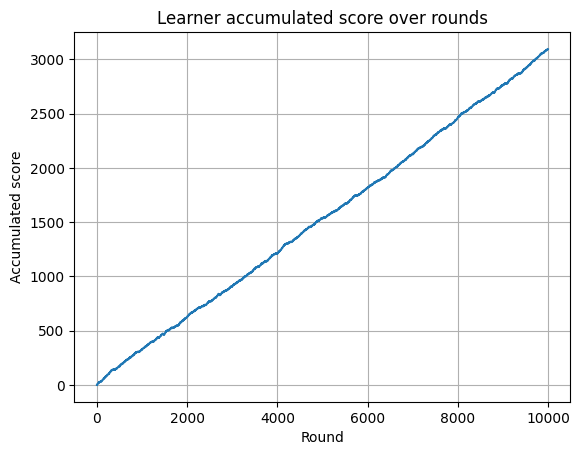

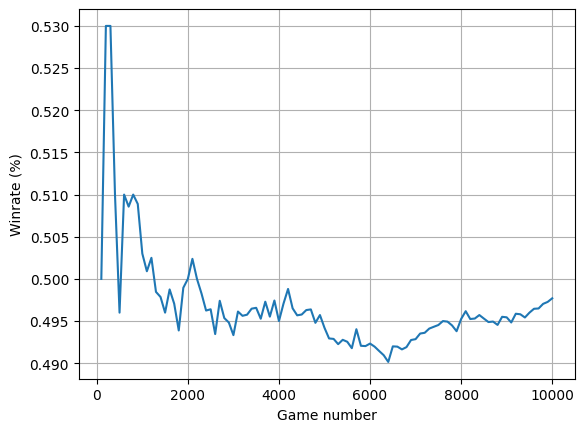

In [92]:
print("================== STATISTICS ==================")
print(f"Games amount: {games_amount}")
print(f"Opponent matrix:\n{opponent_matrix}")
print(f"Learner matrix(normalized):\n{normalize_learner_matrix()}")

print("================== SCORES ==================")
print(f"Draws: {stats['draws']}")
print(f"Learner wins: {stats['learner_wins']}")
print(f"Opponent wins: {stats['opponent_wins']}")

plot_net_advantage()
plot_winrate()